# From simple to advanced, causal inference pipeline

Physical Activity: Does increasing physical activity directly cause a reduction in diabetes risk, or is this effect entirely attributable to confounders?

The **CDC Diabetes Health Indicators Dataset** contains healthcare statistics and lifestyle survey information about people in general along with their diagnosis of diabetes. The 35 features consist of some demographics, lab test results, and answers to survey questions for each patient. The target variable for classification is whether a patient has **diabetes or healthy**.

In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv('/path')

# The causal pipeline

1. Draw a causal DAG

In [3]:
import matplotlib.pyplot as plt
import dowhy
from dowhy import CausalModel
import tqdm as notebook_tqdm

In [4]:
causal_graph = """
digraph {
  age -> physical_activity;
  age -> bmi;
  age -> diabetes_risk;
  sex -> physical_activity;
  sex -> diabetes_risk;
  sex -> bmi;
  ethnicity -> diabetes_risk;
  ethnicity -> bmi;
  physical_activity -> bmi;
  physical_activity -> diabetes_risk;
  bmi -> diabetes_risk;
  income_level -> physical_activity;
  income_level -> bmi;
  income_level -> diabetes_risk;
  education_level -> physical_activity;
  education_level -> diabetes_risk;
  physical_activity -> cholesterol;
  cholesterol -> diabetes_risk;
  genetics -> physical_activity;
  genetics -> diabetes_risk;
  physical_activity -> BP;
  BMI -> BP;
  BP -> diabetes_risk;
  difficulty_walking -> physical activity;
  mental_health -> physical_activity;
  diet -> diabetes_risk
}
"""

In [5]:
df_model = pd.DataFrame(columns=['age','sex','ethnicity','genetics', 'BP','income_level', 'diet','education_level','physical_activity', 'difficulty_walking','diabetes_risk', 'bmi', 'cholesterol'])
df_model.head()

,age,sex,ethnicity,genetics,BP,income_level,diet,education_level,physical_activity,difficulty_walking,diabetes_risk,bmi,cholesterol


/opt/anaconda3/lib/python3.13/site-packages/dowhy/causal_model.py:581: UserWarning: 4 variables are assumed unobserved because they are not in the dataset. Configure the logging level to `logging.WARNING` or higher for additional details.
  warnings.warn(


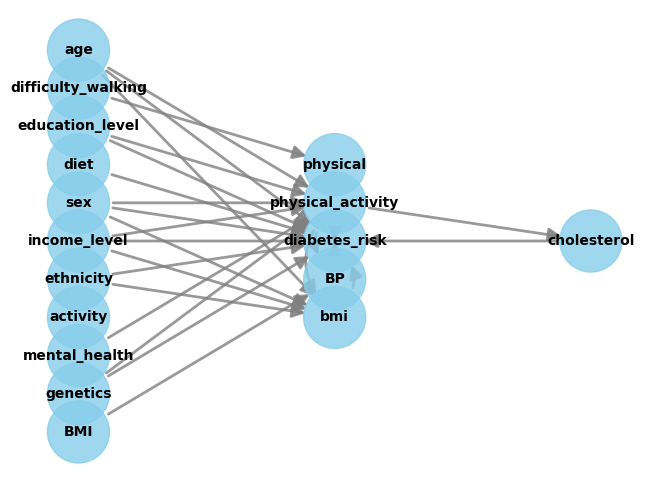

In [6]:
# Define a CausalModel object in DoWhy, indicate treatment & outcome
model= CausalModel(data=df_model, # data columns
        graph=causal_graph, # DAG
        treatment='physical_activity', # cause of interest, X
        outcome='diabetes_risk') # outcome, Y
model.view_model()

# Identification

Identify the causal effect

In [7]:
estimands = model.identify_effect(proceed_when_unidentifiable=True)
print(estimands)

Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
         d                                                                     ↪
────────────────────(E[diabetes_risk|genetics,income_level,sex,education_level ↪
d[physical_activity]                                                           ↪

↪       
↪ ,age])
↪       
Estimand assumption 1, Unconfoundedness: If U→{physical_activity} and U→diabetes_risk then P(diabetes_risk|physical_activity,genetics,income_level,sex,education_level,age,U) = P(diabetes_risk|physical_activity,genetics,income_level,sex,education_level,age)

### Estimand : 2
Estimand name: iv
Estimand expression:
 ⎡                                                                    -1⎤
 ⎢       d                      ⎛       d                            ⎞  ⎥
E⎢───────────────(diabetesᵣᵢₛₖ)⋅⎜───────────────([physical_activity])⎟  ⎥
 ⎣d[mentalₕₑₐₗₜₕ]               ⎝d[mentalₕₑₐₗₜₕ]                     ⎠  ⎦
Estimand a

**Estimand explanation**: To find the true causal effect of physical activity on diabetes risk, you can directly differentiate the expected value of diabetes risk with respect to physical activity as long as you've blocked all "backdoor paths" (confounders).

My understanding of the estimand outout as it relates to the research question: **If you compare people with different physical activity levels, but make sure they are similar in age, sex, genetics, income, and education, then any remaining difference in diabetes risk is truly caused by physical activity.**

# The Data

In [8]:
df.columns.tolist()

['Diabetes_012',
 'HighBP',
 'HighChol',
 'CholCheck',
 'BMI',
 'Smoker',
 'Stroke',
 'HeartDiseaseorAttack',
 'PhysActivity',
 'Fruits',
 'Veggies',
 'HvyAlcoholConsump',
 'AnyHealthcare',
 'NoDocbcCost',
 'GenHlth',
 'MentHlth',
 'PhysHlth',
 'DiffWalk',
 'Sex',
 'Age',
 'Education',
 'Income']

The data shows we have variables that may fit the deconfounding set
* HighBP
* HighChol
* BMI
* Veggies, as a proxy for diet
* MentHlth
* DiffWalk
* Sex
* Age
* Education
* Income

* Exporsure: **PhysActvitiy**, binary yes or no
* Outcome: **Diabetes_012**, multiclass diabetic and healthy

In [9]:
# The existing diabetes data is in 3 classes
# So I changed the diabetes to 2 classes
one = ['1']
df_filtered = df[~df['Diabetes_012'].isin(one)]

In [10]:
my_list = df['Diabetes_012']

In [11]:
# Iterate through indices and replace
for i in range(len(my_list)):
    if my_list[i] == 2:
        my_list[i] = 1
print(f"New diabetes: {my_list}")

New diabetes: 0         0.0
1         0.0
2         0.0
3         0.0
4         0.0
         ... 
253675    0.0
253676    1.0
253677    0.0
253678    0.0
253679    1.0
Name: Diabetes_012, Length: 253680, dtype: float64


In [12]:
# Deconfounding set
# This set must contain age, sex, income, and education because these are the only confounders in the dataset compared to the initial DAG

deconfounding_set = """
digraph {
  Age -> PhysActivity;
  Age -> Diabetes_012;
  Sex -> PhysActivity;
  Sex -> Diabetes_012;
  PhysActivity -> Diabetes_012;
  Income -> PhysActivity;
  Income -> Diabetes_012;
  Education -> PhysActivity;
  Education -> Diabetes_012;
}
"""

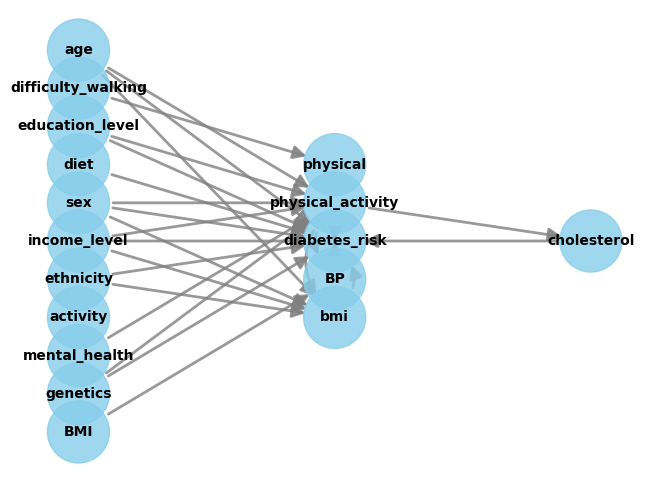

In [13]:
deconfounding_model= CausalModel(data=df, # data columns
        graph=deconfounding_set, # DAG
        treatment='PhysActivity', # exposure
        outcome='Diabetes_012') # outcome
model.view_model()

In [14]:
deconfounding_estimands = deconfounding_model.identify_effect()
print(deconfounding_estimands)

Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
       d                                                 
───────────────(E[Diabetes_012|Income,Sex,Education,Age])
d[PhysActivity]                                          
Estimand assumption 1, Unconfoundedness: If U→{PhysActivity} and U→Diabetes_012 then P(Diabetes_012|PhysActivity,Income,Sex,Education,Age,U) = P(Diabetes_012|PhysActivity,Income,Sex,Education,Age)

### Estimand : 2
Estimand name: iv
No such variable(s) found!

### Estimand : 3
Estimand name: frontdoor
No such variable(s) found!

### Estimand : 4
Estimand name: general_adjustment
Estimand expression:
       d                                                 
───────────────(E[Diabetes_012|Income,Sex,Education,Age])
d[PhysActivity]                                          
Estimand assumption 1, Unconfoundedness: If U→{PhysActivity} and U→Diabetes_012 then P(Diabetes_012|PhysActivity,Income,Sex,Education,Age,U)

Now that we've found adequate measures in our data for all variables in the minimal deconfounding set, and used this data of these measures in our DAG and identification step, we can do estimation.

# Estimation

In [15]:
deconfounding_estimate = deconfounding_model.estimate_effect(deconfounding_estimands,
                                 method_name="backdoor.linear_regression",
                                 effect_modifiers= [],
                                 confidence_intervals=True,
                                 test_significance=True)
print(deconfounding_estimate)

*** Causal Estimate ***

## Identified estimand
Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
       d                                                 
───────────────(E[Diabetes_012|Income,Sex,Education,Age])
d[PhysActivity]                                          
Estimand assumption 1, Unconfoundedness: If U→{PhysActivity} and U→Diabetes_012 then P(Diabetes_012|PhysActivity,Income,Sex,Education,Age,U) = P(Diabetes_012|PhysActivity,Income,Sex,Education,Age)

## Realized estimand
b: Diabetes_012~PhysActivity+Income+Sex+Education+Age
Target units: ate

## Estimate
Mean value: -0.06330766524181261
p-value: [0.]
95.0% confidence interval: [[-0.06659533 -0.06002   ]]



In [16]:
deconfounding_estimate.interpret()

Increasing the treatment variable(s) [PhysActivity] from 0 to 1 causes an increase of -0.06330766524181261 in the expected value of the outcome [['Diabetes_012']], over the data distribution/population represented by the dataset.


# Conclusion from simple causal inference approach

**People who are physically active have a lower diabetes risk score of about 0.12 points compared to people who are not physically active.**

A negative effect means physical activity pulls people toward 0 (healthy) which is exactly what one would expect clinically. This is a good sign that the model is working correctly.

**This is an average effect across the whole population**

# Testing the conclusion with another python stats library

In [17]:
import statsmodels.formula.api as smf

In [18]:
reg_model_all = smf.ols(formula='Diabetes_012 ~ PhysActivity + Age + Sex + Income + Education', data = df)
ols_all = reg_model_all.fit()
print('Effect of physical activity: \n coeff: \t', ols_all.params['PhysActivity'], 
      '\n p value: \t', ols_all.pvalues.loc['PhysActivity'], 
     '\n 95% C.I.s: \t', ols_all.conf_int(alpha = 0.05).loc['PhysActivity'].values)

Effect of physical activity: 
 coeff: 	 -0.06330766524175352 
 p value: 	 0.0 
 95% C.I.s: 	 [-0.06659533 -0.06002   ]


When using the python library **Statsmodel** We get the exact same results as with the DoWhy estimation

# Propensity score

"What is the probability that this person exercises, given their characteristics?"
* Low score (e.g. 0.2) → This person is unlikely to exercise
* High score (e.g. 0.8) → This person is likely to exercise

In [19]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

In [20]:
# Example: 'treatment' = high physical activity (1) vs low (0)
# 1. Prepare covariates
X = df[['Age', 'Education', 'Income', 'Sex']]
y = df['Diabetes_012']

In [21]:
# 2. Scale continuous variables (good practice)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [22]:
# 3. Fit logistic regression
model = LogisticRegression()
model.fit(X_scaled, y)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [23]:
# 4. Extract propensity scores (probability of being treated)
df['propensity_score'] = model.predict_proba(X_scaled)[:, 1]

print(df[['Diabetes_012', 'propensity_score']])

        Diabetes_012  propensity_score
0                0.0          0.239060
1                0.0          0.188877
2                0.0          0.119702
3                0.0          0.235860
4                0.0          0.242339
...              ...               ...
253675           0.0          0.077836
253676           1.0          0.333839
253677           0.0          0.090062
253678           0.0          0.272408
253679           1.0          0.215902

[253680 rows x 2 columns]


# Matching

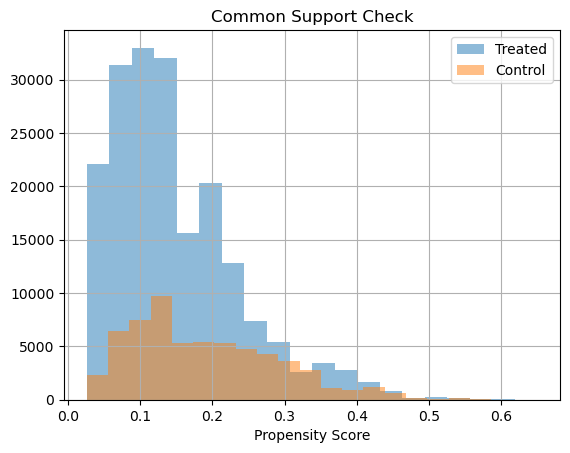

In [24]:
import matplotlib.pyplot as plt

# Overlap plot
df[df.PhysActivity==1]['propensity_score'].hist(alpha=0.5, label='Treated', bins=20)
df[df.PhysActivity==0]['propensity_score'].hist(alpha=0.5, label='Control', bins=20)
plt.xlabel('Propensity Score')
plt.legend()
plt.title('Common Support Check')
plt.show()

The two histograms substantially overlap across a shared range of propensity scores and Neither group is exclusively clustered at 0 or 1, while it appears most propensity scores are at 0.1. This means treated and control units are comparable and that you can find similar counterparts in the other group. ** This good overlap means we can proceed with matching confidently

For every active person, find an inactive person who looks nearly identical in age, education, income and sex
* Discard everyone who can't be matched
* Think of it as: "Compare apples to apples directly"

In [25]:
# Separate treated and control groups
treated = df[df['PhysActivity'] == 1].reset_index(drop=True)
control = df[df['PhysActivity'] == 0].reset_index(drop=True)

# ── 1. Subsample treated to match the size of control pool ────────────────
treated_sampled = treated.sample(n=len(control), 
                                  random_state=42).reset_index(drop=True)

# ── 2. Re-run cKDTree on the sampled treated group ─────────────────────
from scipy.spatial import cKDTree

tree = cKDTree(control['propensity_score'].values.reshape(-1, 1))
distances, matched_control_idx = tree.query(
    treated_sampled['propensity_score'].values.reshape(-1, 1), k=1
)

# ── 3. Rebuild control using ONLY the matched rows ────────────────────────
matched_control = control.iloc[matched_control_idx].reset_index(drop=True)

# ── 4. Verify sizes are now equal ─────────────────────────────────────────
print(f"Treated size:         {len(treated_sampled)}")
print(f"Matched control size: {len(matched_control)}")

Treated size:         61760
Matched control size: 61760


Confounder  SMD Before Matching  SMD After Matching
       Age             0.219296            0.000016
 Education             0.463775            0.000086
    Income             0.459257            0.000025
       Sex             0.075931            0.000065


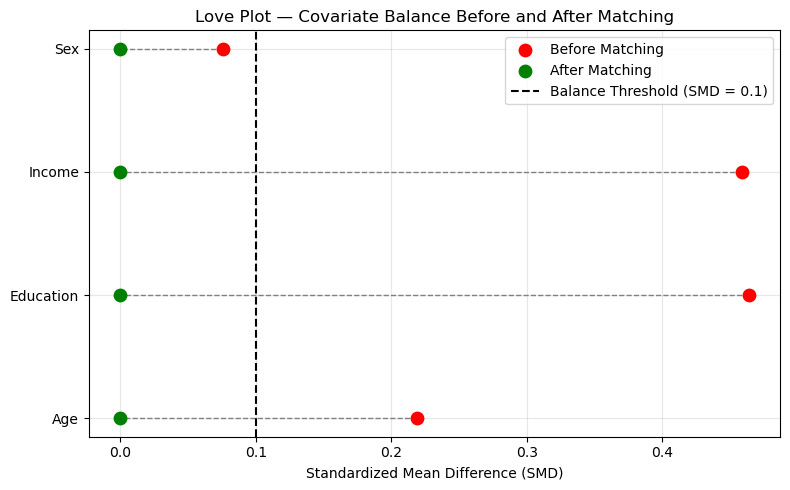

In [26]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# ── 1. Define the confounders we want to check balance on ──────────────────
confounders = ['Age', 'Education', 'Income', 'Sex']


# ── 2. SMD calculation function ────────────────────────────────────────────
def calculate_smd(var_treated, var_control):
    """
    Calculates the Standardized Mean Difference (SMD) between two groups.
    SMD < 0.1 indicates good balance between treated and control groups.
    """
    mean_diff = var_treated.mean() - var_control.mean()
    pooled_std = np.sqrt((var_treated.std()**2 + var_control.std()**2) / 2)
    return abs(mean_diff / pooled_std)

# ── 3. Calculate SMD before and after matching ─────────────────────────────
smd_results = []

for col in confounders:
    # SMD before matching - using the full unmatched dataset
    active_before   = df[df['PhysActivity'] == 1][col]
    inactive_before = df[df['PhysActivity'] == 0][col]
    smd_before = calculate_smd(active_before, inactive_before)

    # SMD after matching - using the matched treated and control groups
    smd_after = calculate_smd(treated_sampled[col], matched_control[col])

    smd_results.append({
        'Confounder': col,
        'SMD Before Matching': smd_before,
        'SMD After Matching':  smd_after
    })

# ── 4. Convert results to a dataframe for easy viewing ─────────────────────
smd_df = pd.DataFrame(smd_results)
print(smd_df.to_string(index=False))

# ── 5. Love Plot visualisation ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))

# Plot SMD before and after matching as dots
ax.scatter(smd_df['SMD Before Matching'], smd_df['Confounder'],
           color='red',  label='Before Matching', zorder=3, s=80)
ax.scatter(smd_df['SMD After Matching'],  smd_df['Confounder'],
           color='green', label='After Matching',  zorder=3, s=80)

# Draw lines connecting before and after for each confounder
for _, row in smd_df.iterrows():
    ax.plot([row['SMD Before Matching'], row['SMD After Matching']],
            [row['Confounder'], row['Confounder']],
            color='grey', linestyle='--', linewidth=1)

# Add the 0.1 balance threshold line
ax.axvline(x=0.1, color='black', linestyle='--',
           linewidth=1.5, label='Balance Threshold (SMD = 0.1)')

# Labels and formatting
ax.set_xlabel('Standardized Mean Difference (SMD)')
ax.set_title('Love Plot — Covariate Balance Before and After Matching')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**What This Tells You**
Before matching the two groups were very different:

Active people tended to be older, more educated and richer
This means any difference in diabetes risk could have been due to these factors, not physical activity

After matching the two groups are now comparable:

Both groups are now similar in age, education, income and sex
Any remaining difference in diabetes risk can now be more confidently attributed to physical activity itself

# Inverse probability weighting

Propensity score summary:
count    253680.000000
mean          0.756521
std           0.148040
min           0.050740
25%           0.694961
50%           0.806380
75%           0.864473
max           0.938364
Name: propensity_score, dtype: float64

IPTW weight summary after stabilisation:
count    253680.000000
mean          0.994190
std           0.336928
min           0.354176
25%           0.854006
50%           0.912093
75%           1.051911
max           2.418655
Name: iptw_weight, dtype: float64

Weighted Logistic Regression Summary:
                 Generalized Linear Model Regression Results                  
Dep. Variable:        diabetes_binary   No. Observations:               253680
Model:                            GLM   Df Residuals:                252192.01
Model Family:                Binomial   Df Model:                           13
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:  

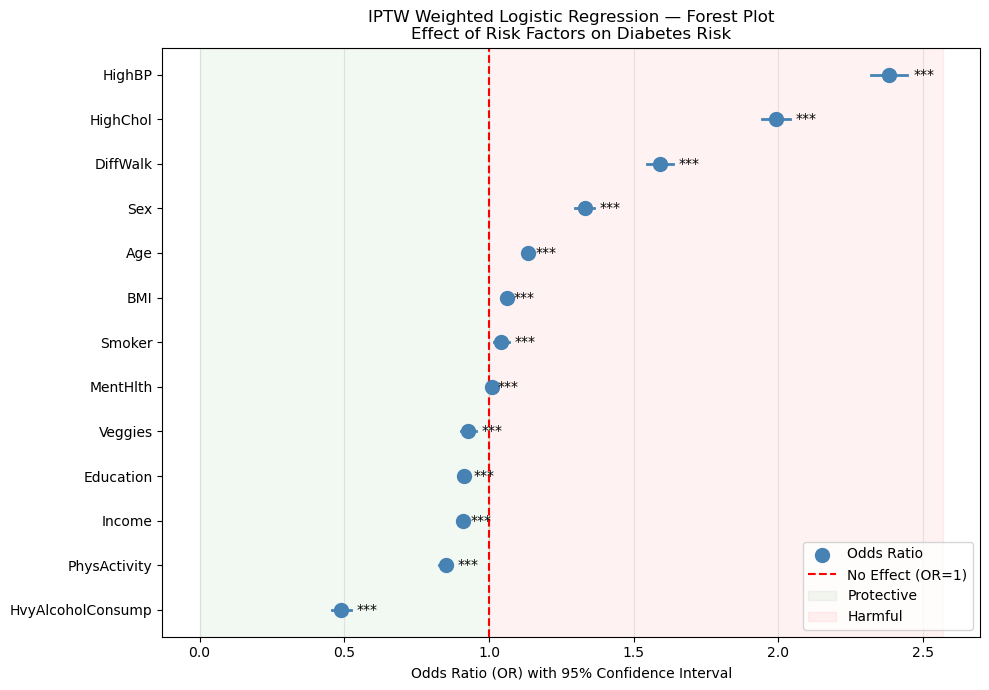

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm
from scipy import stats

# ── 1. Define variables ────────────────────────────────────────────────────
# Risk factors for the outcome model
risk_factors = ['Age', 'Sex', 'Income', 'Education', 'HighBP', 'HighChol', 'BMI', 'Smoker', 'Veggies', 'HvyAlcoholConsump', 'MentHlth', 'DiffWalk']

# Treatment and outcome variables
treatment  = 'PhysActivity'
outcome    = 'Diabetes_012'

# ── 2. Create binary outcome ───────────────────────────────────────────────
# 1 = pre-diabetic or diabetic, 0 = healthy
df['diabetes_binary'] = (df[outcome] >= 1).astype(int)

# ── 3. Calculate Propensity Scores using logistic regression ───────────────
X_treat = df[risk_factors]
y_treat = df[treatment]

# Fit propensity score model
ps_model = LogisticRegression(max_iter=1000, random_state=42)
ps_model.fit(X_treat, y_treat)
df['propensity_score'] = ps_model.predict_proba(X_treat)[:, 1]

print("Propensity score summary:")
print(df['propensity_score'].describe())

# ── 4. Calculate IPTW weights ──────────────────────────────────────────────
# Active group   → weight = 1 / propensity score
# Inactive group → weight = 1 / (1 - propensity score)
df['iptw_weight'] = np.where(
    df[treatment] == 1,
    1 / df['propensity_score'],           # treated
    1 / (1 - df['propensity_score'])      # control
)

# ── 5. Stabilise weights to avoid extreme values ───────────────────────────
# Stabilised weights reduce variance from extreme propensity scores
p_treated = df[treatment].mean()
df['iptw_weight'] = np.where(
    df[treatment] == 1,
    p_treated / df['propensity_score'],
    (1 - p_treated) / (1 - df['propensity_score'])
)

# Trim weights at 1st and 99th percentile to remove outliers
lower = df['iptw_weight'].quantile(0.01)
upper = df['iptw_weight'].quantile(0.99)
df['iptw_weight'] = df['iptw_weight'].clip(lower, upper)

print("\nIPTW weight summary after stabilisation:")
print(df['iptw_weight'].describe())

# ── 6. Fit weighted logistic regression ────────────────────────────────────
# Add physical activity to risk factors for outcome model
outcome_vars = risk_factors + [treatment]
X_outcome    = sm.add_constant(df[outcome_vars])
y_outcome    = df['diabetes_binary']

# Fit weighted logistic regression using IPTW weights
wls_model = sm.GLM(
    y_outcome,
    X_outcome,
    family=sm.families.Binomial(),
    freq_weights=df['iptw_weight']
).fit()

print("\nWeighted Logistic Regression Summary:")
print(wls_model.summary())

# ── 7. Extract Odds Ratios and Confidence Intervals ───────────────────────
results_df = pd.DataFrame({
    'Variable'  : outcome_vars,
    'OR'        : np.exp(wls_model.params[1:]),        # exponentiate coefficients
    'CI_lower'  : np.exp(wls_model.conf_int()[0][1:]), # lower 95% CI
    'CI_upper'  : np.exp(wls_model.conf_int()[1][1:]), # upper 95% CI
    'p_value'   : wls_model.pvalues[1:]
}).reset_index(drop=True)

# Add significance stars
def significance(p):
    if p < 0.001: return '***'
    elif p < 0.01: return '**'
    elif p < 0.05: return '*'
    else: return 'ns'

results_df['significance'] = results_df['p_value'].apply(significance)

print("\nOdds Ratios:")
print(results_df.to_string(index=False))

# ── 8. Forest Plot ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 7))

# Sort by OR for cleaner visualisation
results_df = results_df.sort_values('OR')
y_pos      = range(len(results_df))

# Plot OR points and confidence interval lines
ax.scatter(results_df['OR'], y_pos,
           color='steelblue', zorder=3, s=100, label='Odds Ratio')

# Draw confidence interval lines for each variable
for i, (_, row) in enumerate(results_df.iterrows()):
    ax.plot([row['CI_lower'], row['CI_upper']], [i, i],
            color='steelblue', linewidth=2, zorder=2)
    # Add significance stars next to CI
    ax.text(row['CI_upper'] + 0.02, i, row['significance'],
            va='center', fontsize=10, color='black')

# Add vertical reference line at OR = 1 (no effect)
ax.axvline(x=1, color='red', linestyle='--',
           linewidth=1.5, label='No Effect (OR=1)')

# Shade protective vs harmful regions
ax.axvspan(0, 1, alpha=0.05, color='green', label='Protective')
ax.axvspan(1, ax.get_xlim()[1], alpha=0.05, color='red', label='Harmful')

# Labels and formatting
ax.set_yticks(y_pos)
ax.set_yticklabels(results_df['Variable'])
ax.set_xlabel('Odds Ratio (OR) with 95% Confidence Interval')
ax.set_title('IPTW Weighted Logistic Regression — Forest Plot\nEffect of Risk Factors on Diabetes Risk')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()